## Implementing gradient descent to find a local minimum of a function

In [2]:
#Libraries
import numpy as np
import matplotlib.pylab as plt
import pandas as pd

Function: $f(x) = 2x^2 - 3x + 5$

In [3]:
def f(x):
    return 2*x**2 - 3*x + 5

Derivative: $\frac{df}{dx} = 4x - 3$

In [4]:
def df(x):
    return 4*x - 3

Gradient Descent formula:
$x_{\text{new}} = x_{\text{old}} - \alpha \cdot \frac{df}{dx}$.

Where $\alpha$ is the learning rate, $x_{\text{new}}$ is the current value of $x$ or the value of the previous iteration and $x_{\text{new}}$ is our updated value of $x$ after taking a step along the gradient of the function.

In [5]:
def gradient_descent(x: int, lr: float, iter: int):
    x = 0 # starting point for x (random, usually 0)
    for i in range(iter): #for every iteration
        x = x - lr*df(x) #update x
        if (i + 1) % 10 == 0: # print every 10 iterations
            print(f"Iter {i+1}:  x = {x}, f(x) = {f(x)}")
    return x

In [6]:
minimum = gradient_descent(0.45, 0.1, 100)

Iter 10:  x = 0.7454650368, f(x) = 3.8750411317824502
Iter 20:  x = 0.7499725788116995, f(x) = 3.8750000015038433
Iter 30:  x = 0.7499998341945602, f(x) = 3.875000000000055
Iter 40:  x = 0.7499999989974379, f(x) = 3.875
Iter 50:  x = 0.749999999993938, f(x) = 3.875
Iter 60:  x = 0.7499999999999634, f(x) = 3.875
Iter 70:  x = 0.7499999999999998, f(x) = 3.875
Iter 80:  x = 0.7499999999999999, f(x) = 3.875
Iter 90:  x = 0.7499999999999999, f(x) = 3.875
Iter 100:  x = 0.7499999999999999, f(x) = 3.875


Visualizing gradient descent

In [7]:
x_values = np.linspace(-10, 10, 100)
y_values = f(x_values)

In [8]:
x_values, y_values

(array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
         -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
         -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
         -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
         -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
         -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
         -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
         -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
         -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
         -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
         -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
         -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
         -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
          0.50505051,   0.70707071,   0.90909091,   1.11111111,
          1.31313131,   1.51515152,   1.71717172,   1.91919192,
          2.12121212,   2.32323232,   2.

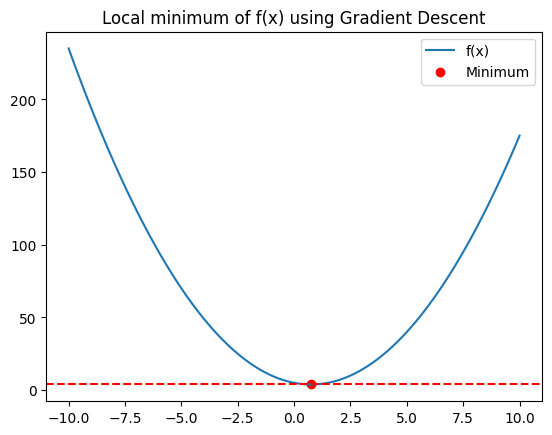

In [9]:
plt.plot(x_values, y_values, label = "f(x)")
plt.scatter(minimum, f(minimum), label = "Minimum", color = "red")
plt.axhline(f(minimum), color="red", linestyle = "--")
plt.title("Local minimum of f(x) using Gradient Descent")
plt.legend()
plt.show()

Learning Curve Visualized

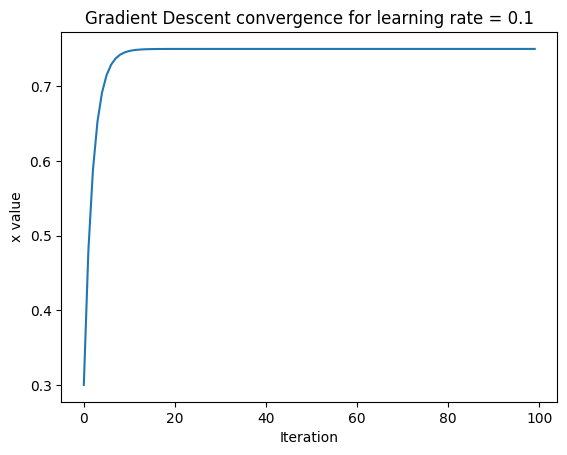

In [10]:
x = 0
lr = 0.1
iter = 100
value_of_x_per_iter = []

for iter in range(iter):
    x = x - lr * df(x)
    value_of_x_per_iter.append(x)

plt.plot(range(iter+1), value_of_x_per_iter)
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Gradient Descent convergence for learning rate = 0.1")
plt.show()


In [11]:
print(np.random.rand(2))

[0.05655864 0.09248316]


## Gradient Descent in Simple Linear Regression

Algorithm steps:
- Start with random initial values for the slope ($m$) and intercept ($b$) of the equation $ y = m x + b $.

- Measure the error using the Mean Squared Error:

     $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - (m x + b))^2 $

- Compute the derivate of the loss function (MSE in our case) with respect to $m$ and $b$:  
    1) $\frac{\partial L}{\partial m}$ 
    
    2) $\frac{\partial L}{\partial b}$

- Update $m$ and $b$ parameters to reduce error in next iteration:  
    1)  $m = m - α\frac{\partial L}{\partial m}$

    2)  $b = b - α\frac{\partial L}{\partial b}$

- Repeat until we reach a local minimum 



### Simple Linear Regression Example

In [12]:
#Example
data = pd.read_csv("D:/Studying/Machine Learning/ML Projects/Linear-Regression/data/test.csv")
data.head(10)

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864
5,15,9.805235
6,62,58.874659
7,95,97.617937
8,20,18.395127
9,5,8.746748


In [13]:
print(data.shape)

(300, 2)


In [14]:
X = data["x"]
Y = data["y"]
print(X)
print(Y)

0      77
1      21
2      22
3      20
4      36
       ..
295    71
296    46
297    55
298    62
299    47
Name: x, Length: 300, dtype: int64
0      79.775152
1      23.177279
2      25.609262
3      17.857388
4      41.849864
         ...    
295    68.545888
296    47.334876
297    54.090637
298    63.297171
299    52.459467
Name: y, Length: 300, dtype: float64


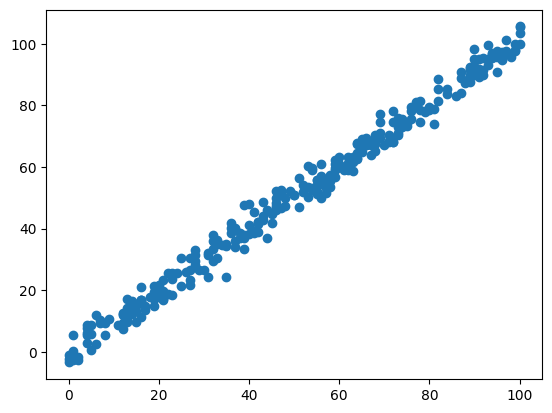

In [19]:
plt.scatter(X, Y)
plt.show()

In [30]:
m = np.random.randn()
b = np.random.randn()
print(m,b)

1.341884684867299 -1.4208399573237658


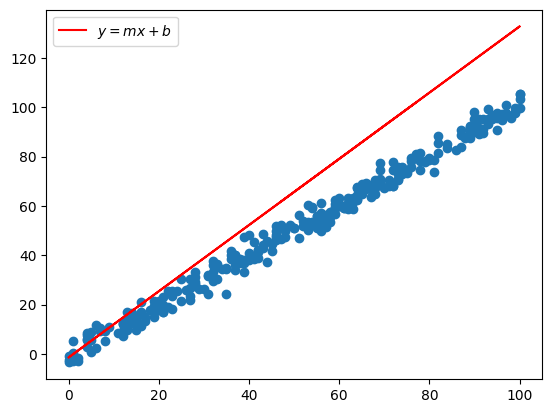

In [37]:
plt.scatter(X, Y)
plt.plot(X, m*X+b, color = "red", label = "$y = mx + b$")
plt.legend()
plt.show()

#### Mean squared error function

In [43]:
def loss_function(Y, Y_pred):
    n = len(Y)
    return (1/n) * sum((Y - Y_pred) ** 2)

In [55]:
m = np.random.randn()
b = np.random.randn()
iter = 100000
lr = 0.0001
n = len(X)

# Loop over all iterations
for i in range(iter):
    y_pred = m * X + b # predictions
    # Gradients
    dM = (-2/n) * np.sum(X * (Y - y_pred))
    dB = (-2/n) * np.sum(Y - y_pred)
    # Compute new m & b parameters
    m = m - lr*dM
    b = b - lr*dB
    # Print loss, m and b every 1000 iterations
    if (i + 1) % 10000 == 0:
        loss = loss_function(Y, y_pred)
        print(f"Iter {i+1}: Loss = {loss}, m = {m}, b = {b}")
    

Iter 10000: Loss = 9.300708936388435, m = 1.0030040487976328, b = 0.2954592600320649
Iter 20000: Loss = 9.216979612685874, m = 1.0072931192835406, b = 0.00882112148815169
Iter 30000: Loss = 9.18463970669538, m = 1.0099587118481466, b = -0.16932015488994206
Iter 40000: Loss = 9.172148628621118, m = 1.0116153373906343, b = -0.28003226916343893
Iter 50000: Loss = 9.167324031063437, m = 1.0126449051589652, b = -0.34883817701431097
Iter 60000: Loss = 9.165460561677111, m = 1.0132847659859296, b = -0.391600010136632
Iter 70000: Loss = 9.164740808762541, m = 1.013682429831358, b = -0.4181758439435852
Iter 80000: Loss = 9.1644628088867, m = 1.013929571908661, b = -0.43469232349941767
Iter 90000: Loss = 9.164355433245138, m = 1.0140831669791606, b = -0.44495706623147674
Iter 100000: Loss = 9.164313960102874, m = 1.014178623996999, b = -0.45133644889587315


In [58]:
print(loss, m, b)

9.164313960102874 1.014178623996999 -0.45133644889587315


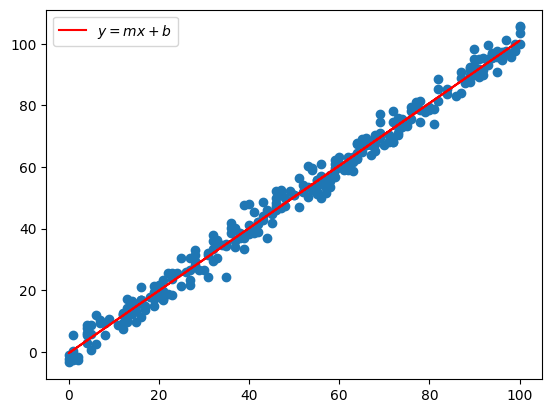

In [59]:
plt.scatter(X, Y)
plt.plot(X, m*X+b, color = "red", label = "$y = mx + b$")
plt.legend()
plt.show()